# 進階QSVM 花卉分類教學（Qiskit + scikit-learn）

本 Notebook 示範如何使用 **QSVM（Quantum Support Vector Machine）** 進行進階的分類任務。

In [1]:
!pip -q install "qiskit>=1.0" qiskit-aer qiskit-machine-learning scikit-learn matplotlib pylatexenc

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import fetch_openml
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

## 🌸 本範例使用資料

我們使用 **Iris dataset（花卉資料）**：

- 每筆資料包含 4 個特徵：
  - 花萼長度（sepal length）
  - 花萼寬度（sepal width）
  - 花瓣長度（petal length）
  - 花瓣寬度（petal width）

- 分類目標：
  - setosa
  - versicolor
  - virginica

In [3]:
n_qubits = 3
reps = 2
test_size = 0.3
random_seed = 42
use_binary = False   # True: 只做兩類花, False: 三類花

In [4]:
# 載入 Iris 資料集
# load_iris() 是 sklearn 內建的資料集
# 不需要下載，直接呼叫即可使用

iris = load_iris()
# X：特徵資料（feature matrix）
# shape = (樣本數, 特徵數) = (150, 4)
# 每一筆資料代表一朵花

X = iris.data
# y：分類標籤（label）
# shape = (150,)
# 每個數字代表一種花的種類（0, 1, 2）

y = iris.target

# target_names：標籤對應的名稱
# ['setosa', 'versicolor', 'virginica']
target_names = iris.target_names

# 如果要做二分類，只保留前兩類

# 如果 use_binary = True：
# 我們只保留前兩類（0 和 1）
# 也就是：
#   setosa 和 versicolor
if use_binary:
  # 建立篩選條件（mask）
  # y < 2 → 只保留 label 為 0 或 1 的資料
    mask = y < 2
    # 用 mask 過濾資料
    X = X[mask]  # 保留對應的特徵
    y = y[mask]  # 保留對應的特徵

    # 同步更新類別名稱（只保留前兩個）
    target_names = target_names[:2]

In [5]:
# 建立 PCA 模型
# n_components = n_qubits：
#   我們希望降維後的資料維度 = 量子電路的 qubit 數
#
# 注意：
# PCA 只能降維（不能升維）
# 所以 n_qubits 不能超過原始特徵數（Iris 是 4）
pca = PCA(n_components=n_qubits)

# fit_transform 做兩件事：
# 1. fit：學習資料的主成分（找出變異最大的方向）
# 2. transform：將資料投影到這些主成分上
X_reduced = pca.fit_transform(X)

print("Original feature dimension:", X.shape[1])
print("Reduced feature dimension:", X_reduced.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)


Original feature dimension: 4
Reduced feature dimension: 3
Explained variance ratio: [0.92461872 0.05306648 0.01710261]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y,
    test_size=test_size,
    random_state=random_seed,
    stratify=y
)

In [7]:
scaler = MinMaxScaler(feature_range=(0, 2*np.pi))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

def build_hea_feature_map(n_qubits, reps=1, entanglement="linear"):
    """
    建立 HEA-style feature map
    - 資料會以參數 x[i] 的形式進入旋轉閘
    - 每層包含：
        1. 單量子位資料編碼
        2. 糾纏層
    """
    x = ParameterVector("x", n_qubits)
    qc = QuantumCircuit(n_qubits)

    for _ in range(reps):
        # data encoding layer
        for i in range(n_qubits):
            qc.ry(x[i], i)
            qc.rz(x[i], i)

        # entanglement layer
        if entanglement == "linear":
            for i in range(n_qubits - 1):
                qc.cx(i, i + 1)
        elif entanglement == "circular":
            for i in range(n_qubits - 1):
                qc.cx(i, i + 1)
            if n_qubits > 2:
                qc.cx(n_qubits - 1, 0)
        elif entanglement == "full":
            for i in range(n_qubits):
                for j in range(i + 1, n_qubits):
                    qc.cx(i, j)
        else:
            raise ValueError("entanglement must be 'linear', 'circular', or 'full'")

    return qc

In [9]:
print("X_train range:")
print("min:", X_train.min())
print("max:", X_train.max())

X_train range:
min: 0.0
max: 6.283185307179586


In [10]:
feature_map = build_hea_feature_map(n_qubits=3, reps=2)

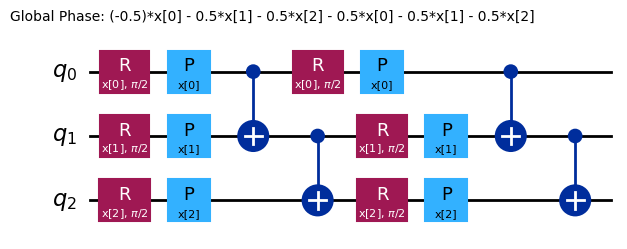

In [11]:
feature_map.decompose().draw("mpl", fold=100)

In [12]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

In [13]:
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

y_pred = qsvc.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nQSVM accuracy =", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=target_names))


QSVM accuracy = 0.8889

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



In [14]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

Confusion matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]


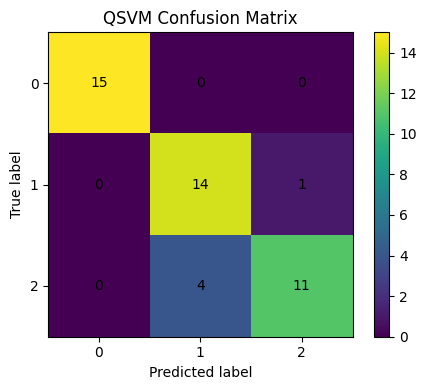

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# 計算 confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 畫圖
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest')
plt.title("QSVM Confusion Matrix")
plt.colorbar()

# 標籤
classes = np.unique(y_test)
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# 在格子中顯示數字
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

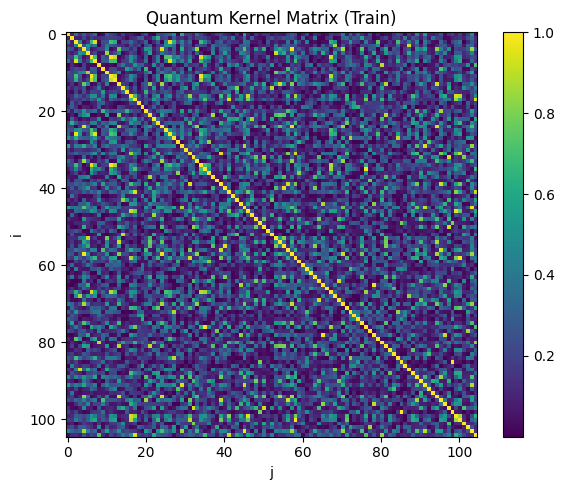

In [16]:
K_train = quantum_kernel.evaluate(X_train)

plt.figure(figsize=(6, 5))
plt.imshow(K_train, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.title("Quantum Kernel Matrix (Train)")
plt.xlabel("j")
plt.ylabel("i")
plt.tight_layout()
plt.show()